# Rayleigh-Bénard convection of a Darcy-Brinkman fluid in a partially porous rectangle

$$
\mathbb{S}_{\textbf{u},p,c}
\begin{cases}
\Omega = [0, \mathcal{A}X] \times [0, X] & \text{aspect ratio } \mathcal{A}=\mathcal{O}(1) \\
c_0(x, y)=1-y/X+\mathcal{N}(x,y) & \text{perturbed initial concentration} \\
\textbf{u}_0=\textbf{0} & \text{static initial velocity} \\
p_0=0 & \text{static initial pressure} \\
c_{\text{D}}(x,y=0)=1 & \text{light lower boundary} \\
c_{\text{D}}(x,y=X)=0 & \text{heavy upper boundary} \\
c_{\text{N}}(x=0,y)=0 & \text{no-flux on left boundary}\\
c_{\text{N}}(x=\mathcal{A}X,y)=0 & \text{no-flux on right boundary}\\
\textbf{u}_{\text{E}}\vert_{\partial\Omega}=\textbf{0} & \text{no-flow on entire boundary} \\
\phi = 1 & \text{constant porosity} \\
\mathsf{D} = \mathsf{I} & \text{constant isotropic dispersion}\\ 
\mathsf{K}^{-1} = \text{H}(y-\tfrac{1}{2}X)\mathsf{I} & \text{isotropic inverse permeability}\\ 
\mu=1 & \text {constant viscosity} \\
\rho(c) = -c & \text{linear density} \\ 
\textbf{e}_g=-\textbf{e}_y & \text{vertically downward gravity} \\
\end{cases}
$$

In [ ]:
from lucifex.sim import run
from lucifex.plt import (
    plot_colormap, plot_line, plot_streamlines, save_figure,
    create_animation, display_animation,
)
from lucifex.solver import maximum
from lucifex.utils.fenicsx_utils import extract_component_functions
from py.C41_darcy_brinkman_rayleigh_benard import darcy_brinkman_rayleigh_benard_rectangle

Pr = 1.0
Ra = 1e7
Dr = 1e-5
simulation = darcy_brinkman_rayleigh_benard_rectangle(
    aspect=2.0, 
    Nx=64,
    Ny=64,
    cell='quadrilateral',
    Pr=Pr,
    Ra=Ra,
    Dr=Dr,
    noise_eps=1e-2,
    dt_max=0.01, 
    dt_courant=0.25,
)

n_stop = 1000
dt_init = 1e-6
n_init = 10
run(simulation, n_stop=n_stop, dt_init=dt_init, n_init=n_init)

c, u, kInv = simulation['c', 'u', 'kInv']

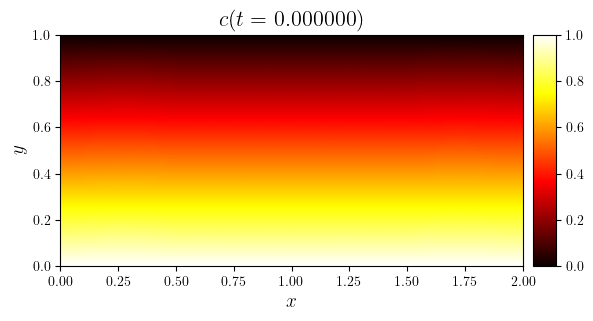

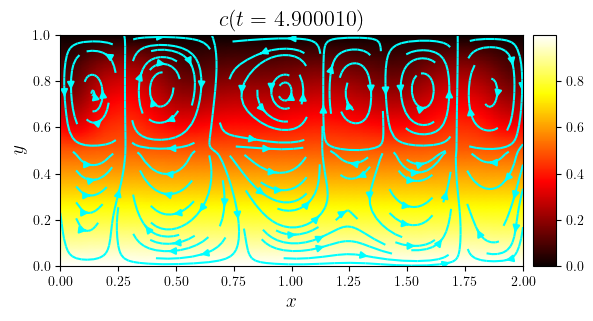

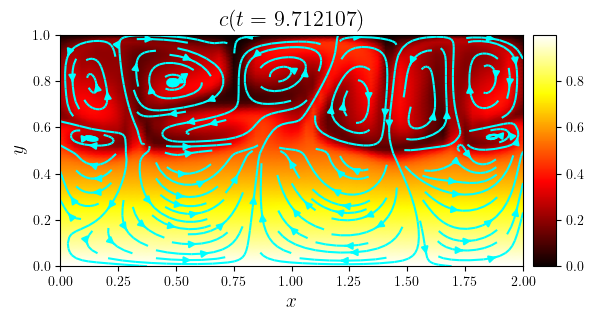

In [3]:
time_indices = (0, int(0.5 * n_stop), -1)
for i in time_indices:
    ti = c.time_series[i]
    ci = c.series[i]
    ui = u.series[i]
    uxi, uyi = extract_component_functions(('P', 1), ui, names=('ux', 'uy'))
    fig, ax = plot_colormap(c.series[i], title=f'$c(t={ti:.6f})$')
    plot_streamlines(fig, ax, (uxi, uyi), color='cyan')
    save_figure(f'c(t={ti:.2f})_streamlines', thumbnail=(i is time_indices[-1]))(fig)

In [5]:
time_slice = slice(0, None, 10)
titles = [f'$c(t={t:.6f})$' for t in c.time_series[time_slice]]

anim = create_animation(
    plot_colormap,
    colorbar=False,
)(c.series[time_slice], title=titles)
anim_path = save_figure(f'c(x,y,t)', return_path=True)(anim)

display_animation(anim_path)

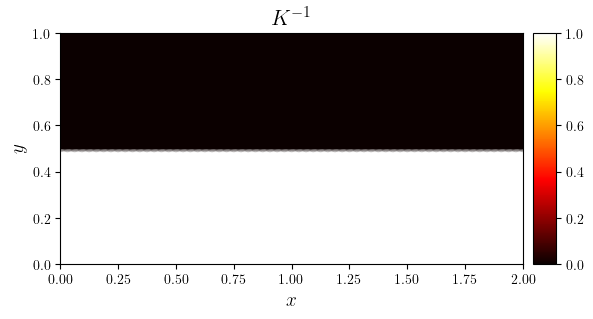

In [6]:
fig, ax = plot_colormap(kInv, title='$K^{-1}$')

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$t$', ylabel='$\\max_{\\mathbf{x}}|\\textbf{u}|$'>)

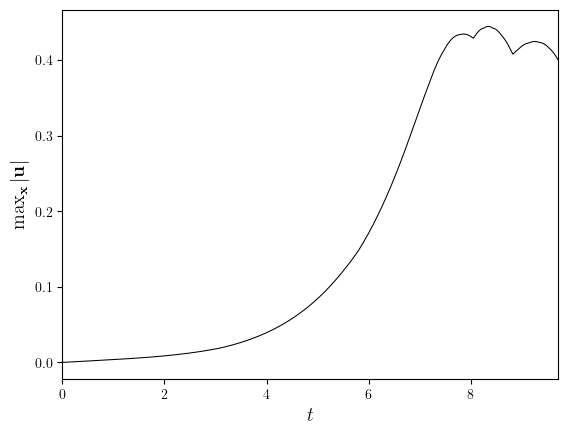

In [ ]:
u = simulation['u']
uMax = [maximum(i) for i in u.series]

fig, ax = plot_line(
    (u.time_series, uMax), 
    x_label='$t$', 
    y_label='$\max_{\\mathbf{x}}|\\textbf{u}|$',
)
save_figure(f'uMax(t)')(fig)